In [1]:
import pandas as pd
# load the data
ratings = pd.read_csv("../data/u.data", sep="\t", names=["user_id","item_id","rating","timestamp"])
movies = pd.read_csv("../data/u.item", sep="|", encoding="latin-1",
                     names=["item_id","title","release_date","video_release","imdb_url"] + [str(i) for i in range(19)])

ratings.head()
movies.head()

,item_id,title,release_date,video_release,imdb_url,0,1,2,3,4,...,9,10,11,12,13,14,15,16,17,18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [2]:
# merge the data
data = pd.merge(ratings, movies, on="item_id")
data.head()

,user_id,item_id,rating,timestamp,title,release_date,video_release,imdb_url,0,1,...,9,10,11,12,13,14,15,16,17,18
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
print("Total Users:", data['user_id'].nunique())
print("Total Movies:", data['item_id'].nunique())

Total Users: 943
Total Movies: 1682


In [4]:
# Top rated Movies
top_movies = data.groupby('title')['rating'].mean().sort_values(ascending=False)
top_movies.head(10)

title
Aiqing wansui (1994)                                 5.0
Entertaining Angels: The Dorothy Day Story (1996)    5.0
Santa with Muscles (1996)                            5.0
Prefontaine (1997)                                   5.0
They Made Me a Criminal (1939)                       5.0
Saint of Fort Washington, The (1993)                 5.0
Great Day in Harlem, A (1994)                        5.0
Star Kid (1997)                                      5.0
Marlene Dietrich: Shadow and Light (1996)            5.0
Someone Else's America (1995)                        5.0
Name: rating, dtype: float64

In [5]:
# most rated movies
popular = data['title'].value_counts().head(10)
popular

title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: count, dtype: int64

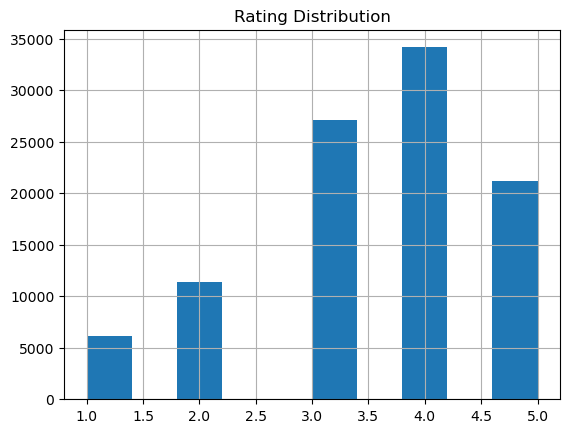

In [6]:
import matplotlib.pyplot as plt

data['rating'].hist()
plt.title("Rating Distribution")
plt.show()

## Most ratings are between 3–5
## Few movies have very high number of ratings
## Dataset is sparse (not every user rates every movie)